# SWAP Test

量子SWAP Test是一种量子算法，用于测量两个量子态的重叠程度，即它们的内积的模的平方。这个算法非常有用，因为它允许我们在不知道量子态具体内容的情况下估计它们之间的相似度。

### SWAP Test的设置

为了进行SWAP Test，我们需要准备三个量子比特：

1. **控制寄存器**：一个量子比特，初始状态为$|0\rangle$。
2. **目标寄存器A**：其中一个量子比特或多个量子比特组成的寄存器，其初始状态为$|\psi\rangle$。
3. **目标寄存器B**：另一个量子比特或多个量子比特组成的寄存器，其初始状态为$|\phi\rangle$。

### SWAP Test算法步骤

1. **初始化**：
   准备控制寄存器的量子比特在状态$|0\rangle$，目标寄存器A在状态$|\psi\rangle$，目标寄存器B在状态$|\phi\rangle$。

2. **应用Hadamard门**：
   对控制寄存器的量子比特应用一个Hadamard门$H$，将其置于叠加态：

   $$ \frac{|0\rangle + |1\rangle}{\sqrt{2}} $$

3. **应用受控SWAP操作**：
   对目标寄存器A和B执行一个受控SWAP操作。这个操作会在控制寄存器处于$|1\rangle$状态时交换A和B寄存器的状态。在控制寄存器处于$|0\rangle$状态时则不做任何操作。

   在这一步之后，系统的整体状态变为：

   $$ \frac{|0\rangle|\psi\rangle|\phi\rangle + |1\rangle|\phi\rangle|\psi\rangle}{\sqrt{2}} $$

4. **再次应用Hadamard门**：
   再次对控制寄存器的量子比特应用Hadamard门。

   这一步操作后，系统的整体状态变为：

   $$ \frac{1}{2}(|0\rangle(|\psi\rangle|\phi\rangle + |\phi\rangle|\psi\rangle) + |1\rangle(|\psi\rangle|\phi\rangle - |\phi\rangle|\psi\rangle)) $$

5. **测量控制寄存器**：
   最后，测量控制寄存器。如果两个目标寄存器的状态相同，控制寄存器将100%测量为$|0\rangle$。如果状态完全不同，则控制寄存器测量为$|0\rangle$和$|1\rangle$的概率各为50%。

   测量控制寄存器得到$|0\rangle$的概率是：

   $$ P(0) = \frac{1}{2} + \frac{1}{2}|\langle\psi|\phi\rangle|^2 $$

   测量控制寄存器得到$|1\rangle$的概率是：

   $$ P(1) = \frac{1}{2} - \frac{1}{2}|\langle\psi|\phi\rangle|^2 $$

通过这些概率，我们可以计算出$|\langle\psi|\phi\rangle|^2$，即两个量子态的重叠程度。

### 代码实例

取 $\left|\phi\right\rangle=\frac{\left|0\right\rangle+\left|1\right\rangle}{\sqrt2},\left|\psi\right\rangle=\left|1\right\rangle$ ，SWAP Test的一个DeepQuantum代码实例如下：

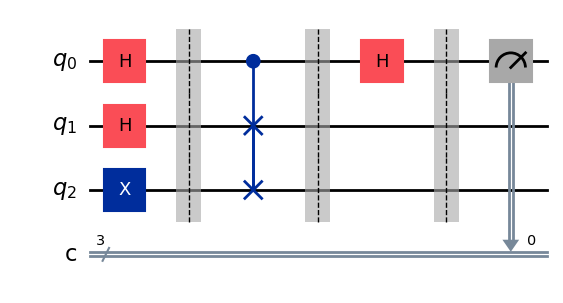

In [ ]:
import deepquantum as dq


def swap_test():
    cir = dq.QubitCircuit(3)

    # 应用Hadamard门
    cir.h(0)
    cir.h(1)
    cir.x(2)
    cir.barrier()

    # 控制操作
    cir.swap([1, 2], 0)
    cir.barrier()

    # 再次应用Hadamard门
    cir.h(0)
    cir.barrier()

    # 测量控制寄存器
    cir.measure(wires=0)

    return cir


# 绘制量子线路图
swap_test_circuit = swap_test()
swap_test_circuit.draw()

输出结果应如下所示，分别以 0.75 和 0.25 的概率得到 $\ket{0}$ 和 $\ket{1}$ ：

In [ ]:
swap_test_circuit()
res = swap_test_circuit.measure(shots=10000)

# 筛选出第一位为 '0' 的键，并计算这些键对应的值的总和
first_digit_zero_sum = sum(value for key, value in res.items() if key.startswith('0'))
first_digit_one_sum = sum(value for key, value in res.items() if key.startswith('1'))
# 计算所有值的总和
total_sum = sum(res.values())

# 计算比例
p_0 = first_digit_zero_sum / total_sum
p_1 = first_digit_one_sum / total_sum

print('p_0:' + str(p_0))
print('p_1:' + str(p_1))

p_0:0.7609
p_1:0.2391
